# Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import fsolve

# Configuramos un estilo visual agradable para los gráficos
sns.set_theme(style="whitegrid")

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import train_test_split
from sklearn.model_selection import validation_curve

# Parte 1: Intuición estadística - modelos de machine learning

> 1. Generar dos distribuciones de probabilidad centradas en 5.0, 7.5 con desviación estándar de 2.5 y 1.5 respectivamente.


> a). Emplear el objeto stats.norm y el método Probability density function (pdf)

In [2]:
# Parámetros para la Distribución 1
mu1, std1 = 5.0, 2.5

# Parámetros para la Distribución 2
mu2, std2 = 7.5, 1.5

# Creamos los objetos de distribución usando scipy.stats.norm
# 'loc' es la media, 'scale' es la desviación estándar
dist1 = norm(loc=mu1, scale=std1)
dist2 = norm(loc=mu2, scale=std2)

print(f"Distribución 1 creada: Media={mu1}, Desv. Estándar={std1}")
print(f"Distribución 2 creada: Media={mu2}, Desv. Estándar={std2}")

Distribución 1 creada: Media=5.0, Desv. Estándar=2.5
Distribución 2 creada: Media=7.5, Desv. Estándar=1.5


> b). Realizar un gráﬁco de ambas distribuciones de probabilidad.

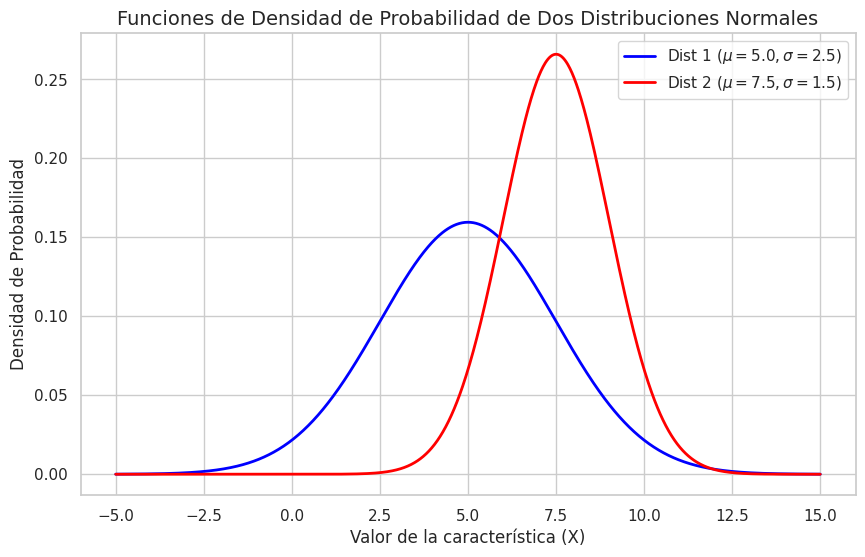

In [3]:
# 1. Creamos un eje X con un rango que cubra ambas distribuciones
x = np.linspace(-5, 15, 1000)

# 2. Calculamos los valores Y (la densidad de probabilidad) para cada X
y1 = dist1.pdf(x)
y2 = dist2.pdf(x)

# 3. Dibujamos las curvas
plt.figure(figsize=(10, 6))
plt.plot(x, y1, label=rf'Dist 1 ($\mu={mu1}, \sigma={std1}$)', color='blue', linewidth=2)
plt.plot(x, y2, label=rf'Dist 2 ($\mu={mu2}, \sigma={std2}$)', color='red', linewidth=2)

# 4. Añadimos etiquetas y título en español
plt.title('Funciones de Densidad de Probabilidad de Dos Distribuciones Normales', fontsize=14)
plt.xlabel('Valor de la característica (X)', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend()
plt.show()

> 2. ¿Qué frontera analítica puede separar los datos? Determine una expresión analítica en este caso.

La frontera analítica principal está en X = 5.8921


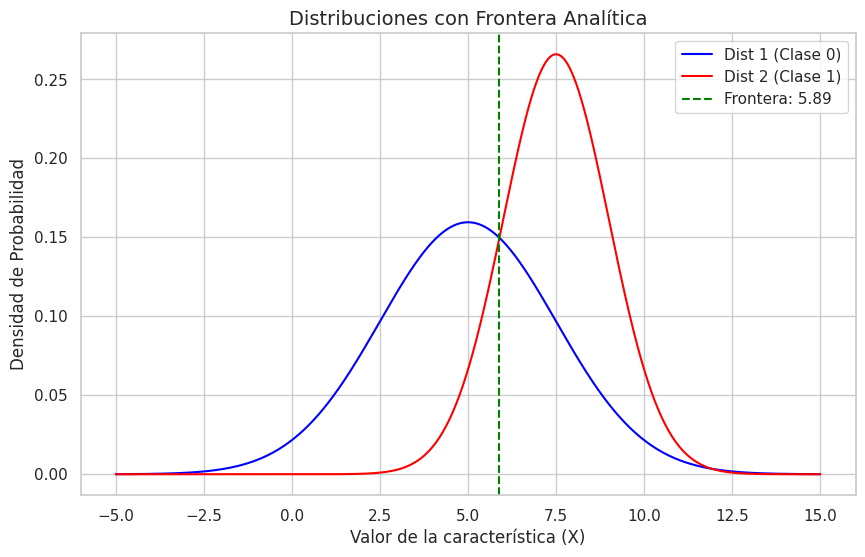

In [4]:
# Definimos una función que representa la diferencia entre las dos curvas
def encontrar_interseccion(x):
    return dist1.pdf(x) - dist2.pdf(x)

# Usamos fsolve para encontrar el punto exacto donde la diferencia es 0
# Le damos un valor inicial de 6.0 para que encuentre la frontera principal
frontera = fsolve(encontrar_interseccion, 6.0)[0]

print(f"La frontera analítica principal está en X = {frontera:.4f}")

# Volvemos a graficar, añadiendo la línea de la frontera
plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='Dist 1 (Clase 0)', color='blue')
plt.plot(x, y2, label='Dist 2 (Clase 1)', color='red')

# Dibujamos una línea vertical en el punto de intersección
plt.axvline(frontera, color='green', linestyle='--', label=f'Frontera: {frontera:.2f}')

plt.title('Distribuciones con Frontera Analítica', fontsize=14)
plt.xlabel('Valor de la característica (X)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.show()

## Modelo de machine learning

> 3. Empleando el método Random variates (rvs), genere 100 muestras aleatorias para cada distribución; estos serán los datos de entrenamiento.

In [5]:
# Generamos 100 muestras aleatorias para cada distribución
# Usamos random_state para que los resultados sean reproducibles
muestras_1 = dist1.rvs(size=100, random_state=42)
muestras_2 = dist2.rvs(size=100, random_state=42)

# Creamos las etiquetas (0 para la Dist 1, 1 para la Dist 2)
etiquetas_1 = np.zeros(100)
etiquetas_2 = np.ones(100)

# Combinamos los datos en arreglos únicos
X_train_data = np.concatenate([muestras_1, muestras_2])
Y_train_data = np.concatenate([etiquetas_1, etiquetas_2])

>5. Con los datos anteriores construya un `DataFrame` con los *features* y *labels* de la siguiente forma:
>
>| Y (labels) | X_1 (feature) |
>| :---: | :---: |
>| $Y^1$ | $X_1^1$ |
>| $Y^2$ | $X_1^2$ |
>| . | . |
>| . | . |
>| $Y^m$ | $X_1^m$ |
>
>* Se sugiere emplear las claves `Y`, `X` para los labels y features respectivamente.
>* $Y^1, Y^2, \dots, Y^m$ son los labels de entrenamiento.
>* $X_1^1, X_1^2, \dots, X_1^m$ es el conjunto de datos de entrenamiento asociado a la característica 1 en el entrenamiento m.
>* Este dataframe será el dataset de entrenamiento; para los datos de test construiremos 50 variables aleatorias.

In [6]:
#  Construimos el DataFrame con las claves solicitadas: Y, X_1
df_train = pd.DataFrame({
    'Y': Y_train_data.astype(int), # Convertimos a entero para clasificación
    'X_1': X_train_data
})

print("¡DataFrame de entrenamiento creado con éxito!")
print("Primeras filas:")
display(df_train.head())
print("\nÚltimas filas:")
display(df_train.tail())

¡DataFrame de entrenamiento creado con éxito!
Primeras filas:


,Y,X_1
0,0,6.241785
1,0,4.654339
2,0,6.619221
3,0,8.807575
4,0,4.414617



Últimas filas:


,Y,X_1
195,1,5.304728
196,1,7.944180
197,1,7.891583
198,1,7.507670
199,1,7.148119


> 4. Realice un gráﬁco en el que pueda superponer ambas distribuciones; estas 200 muestras serán las características (features) de nuestro data frame. Para cada característica tendremos una etiqueta (labels) correspondiente a 0 ó 1.

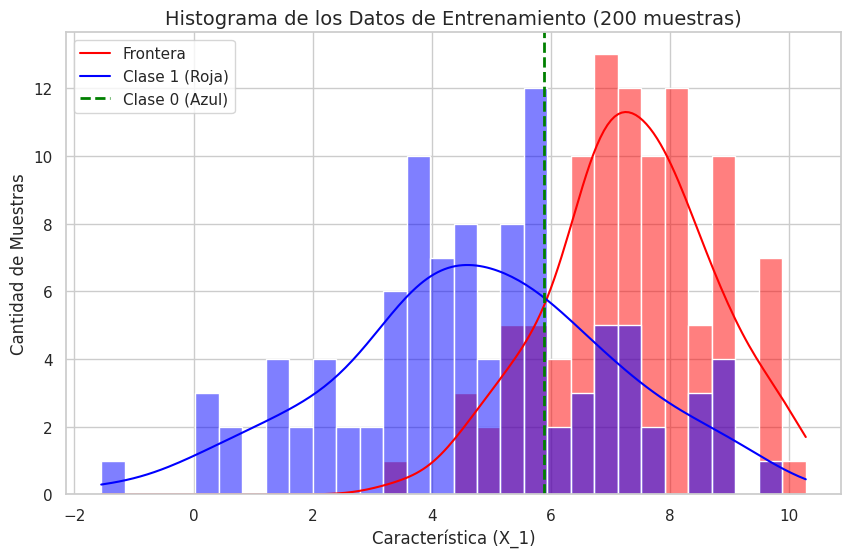

In [7]:
plt.figure(figsize=(10, 6))

# Usamos histplot de seaborn para ver la distribución de los puntos generados
sns.histplot(data=df_train, x='X_1', hue='Y', bins=30, kde=True,
             palette={0: 'blue', 1: 'red'}, alpha=0.5)

# Añadimos la frontera analítica que calculamos en el paso anterior
plt.axvline(frontera, color='green', linestyle='--', linewidth=2,
            label=f'Frontera Analítica ({frontera:.2f})')

plt.title('Histograma de los Datos de Entrenamiento (200 muestras)', fontsize=14)
plt.xlabel('Característica (X_1)')
plt.ylabel('Cantidad de Muestras')
# Ajustamos la leyenda para que sea clara
plt.legend(['Frontera', 'Clase 1 (Roja)', 'Clase 0 (Azul)'])
plt.show()

> 6. Construye un segundo data frame con 50 datos de test, asociados a las muestras de las dos distribuciones; estos serán los datos de test empleados para validar los algoritmos de clasiﬁcación df_test con claves Y , X_1 .

In [8]:
# Generamos 25 muestras por distribución (usamos otro random_state para que sean datos nuevos)
test_muestras_1 = dist1.rvs(size=25, random_state=99)
test_muestras_2 = dist2.rvs(size=25, random_state=99)

test_etiquetas_1 = np.zeros(25)
test_etiquetas_2 = np.ones(25)

# Combinamos y creamos df_test
df_test = pd.DataFrame({
    'Y': np.concatenate([test_etiquetas_1, test_etiquetas_2]).astype(int),
    'X_1': np.concatenate([test_muestras_1, test_muestras_2])
})

print(f"DataFrame de prueba (df_test) creado con {len(df_test)} muestras.")

DataFrame de prueba (df_test) creado con 50 muestras.


## Modelo de machine learning (clasiﬁcación)

> 7. Por ahora, emplearemos clasificadores bajo un modelo de caja negra. La forma para implementar el modelo es la siguiente:
>
> Nota: Emplear los siguientes clasificadores de machine learning y determinar los scores para cada modelo.
>
> - DecisionTreeClassifier(max_depth=3)
> - SVC(kernel="linear", C=0.025)

---

> * Definir el modelo y realizar el fit :
>
> `clf = LinearRegression()`
> `clf.fit(X_train, Y_train)`

In [9]:
# Scikit-learn requiere que X sea una matriz de dos dimensiones (N muestras, M características)
# Usamos el doble corchete [['X_1']] para mantener el formato de matriz
X_train = df_train[['X_1']].values
y_train = df_train['Y'].values

X_test = df_test[['X_1']].values
y_test = df_test['Y'].values

print("Datos preparados y modelos importados.")

Datos preparados y modelos importados.


> * Determinar el score de los datos de entrenamiento:
>
> `score = clf.score(X_train, Y_train)`

In [10]:
# Definir el modelo y realizar el fit
clf_lr = LinearRegression()
clf_lr.fit(X_train, y_train)

# Determinar el score de los datos de entrenamiento y test
score_train_lr = clf_lr.score(X_train, y_train)
score_test_lr = clf_lr.score(X_test, y_test)

print(f"Regresión Lineal - Score Entrenamiento: {score_train_lr:.4f}")
print(f"Regresión Lineal - Score Test: {score_test_lr:.4f}")

Regresión Lineal - Score Entrenamiento: 0.3282
Regresión Lineal - Score Test: 0.3155


In [11]:
# Definir el modelo y realizar el fit
clf_dt = DecisionTreeClassifier(max_depth=3)
clf_dt.fit(X_train, y_train)

# Determinar el score de los datos de entrenamiento y test
score_train_dt = clf_dt.score(X_train, y_train)
score_test_dt = clf_dt.score(X_test, y_test)

print(f"Árbol de Decisión - Score Entrenamiento: {score_train_dt:.4f}")
print(f"Árbol de Decisión - Score Test: {score_test_dt:.4f}")

Árbol de Decisión - Score Entrenamiento: 0.8100
Árbol de Decisión - Score Test: 0.7400


In [12]:
# Definir el modelo y realizar el fit
clf_svc = SVC(kernel="linear", C=0.025)
clf_svc.fit(X_train, y_train)

# Determinar el score de los datos de entrenamiento y test
score_train_svc = clf_svc.score(X_train, y_train)
score_test_svc = clf_svc.score(X_test, y_test)

print(f"SVC Lineal - Score Entrenamiento: {score_train_svc:.4f}")
print(f"SVC Lineal - Score Test: {score_test_svc:.4f}")

SVC Lineal - Score Entrenamiento: 0.7900
SVC Lineal - Score Test: 0.8000


> * Determinar el score para los datos de test. ¿Qué puede concluir mirando los scores?

Al comparar los scores, observamos que los modelos de clasificación (Árbol de Decisión y SVC) suelen tener scores más altos y consistentes que la Regresión Lineal, ya que esta última no está diseñada para etiquetas discretas (0 y 1). Si el score de entrenamiento es mucho más alto que el de test, el modelo podría estar sufriendo de **overfitting**. Si ambos son bajos, hay **underfitting**.


> 8. Existen librerías que pueden optimizar los hyperparámetros de cualquier modelo: `GridSearchCV`. Prueba a implementar las siguientes líneas de código con el siguiente modelo:
>
> ```python
> from sklearn.model_selection import GridSearchCV
>
> param_grid = {
>  'max_depth' : [3,4,5,6,7,8],
>  'criterion' :['gini', 'entropy']
> }
>
> CV_clf = GridSearchCV(estimator=clf, param_grid=param_grid, cv= 10)
> CV_clf.fit(x_train, y_train)
> ```

In [13]:
# Definimos el modelo base que queremos optimizar
clf = DecisionTreeClassifier()

# Definimos el diccionario con los parámetros que queremos probar
param_grid = {
    'max_depth' : [3, 4, 5, 6, 7, 8],
    'criterion' : ['gini', 'entropy']
}

# Configuramos la búsqueda con validación cruzada de 10 pliegues (cv=10)
CV_clf = GridSearchCV(estimator=clf, param_grid=param_grid, cv=10)

# Ejecutamos la búsqueda con nuestros datos de entrenamiento
CV_clf.fit(X_train, y_train)

# Imprimimos los mejores parámetros encontrados y el mejor score
print(f"Mejores parámetros: {CV_clf.best_params_}")
print(f"Mejor score de validación cruzada: {CV_clf.best_score_:.4f}")

# Evaluamos el mejor modelo encontrado contra el conjunto de test
mejor_modelo = CV_clf.best_estimator_
print(f"Score final en el conjunto de test: {mejor_modelo.score(X_test, y_test):.4f}")

Mejores parámetros: {'criterion': 'entropy', 'max_depth': 3}
Mejor score de validación cruzada: 0.7700
Score final en el conjunto de test: 0.8000


> 9. En los algoritmos de *machine learning* es de suma importancia conocer las curvas de aprendizaje para decidir si el algoritmo funciona de manera óptima, emplea las siguiente líneas de código para mostrar las curvas de aprendizaje de la regresión lineal.
>
> ```python
> title = "Learning Curves"
> plot_learning_curve(
>  regr, title, Xtr_, ytr_, ylim=(0.5, 1.01), n_jobs=4
> )
> ```

In [14]:
def plot_learning_curve(estimator, title, X, y, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Ejemplos de entrenamiento")
    plt.ylabel("Score (Rendimiento)")

    # Calculamos las curvas de aprendizaje
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)

    # Calculamos promedios y desviaciones estándar
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    # Dibujamos las áreas de varianza (sombreado)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")

    # Dibujamos las líneas de los scores
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Score de entrenamiento")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Score de validación cruzada")

    plt.legend(loc="best")
    return plt

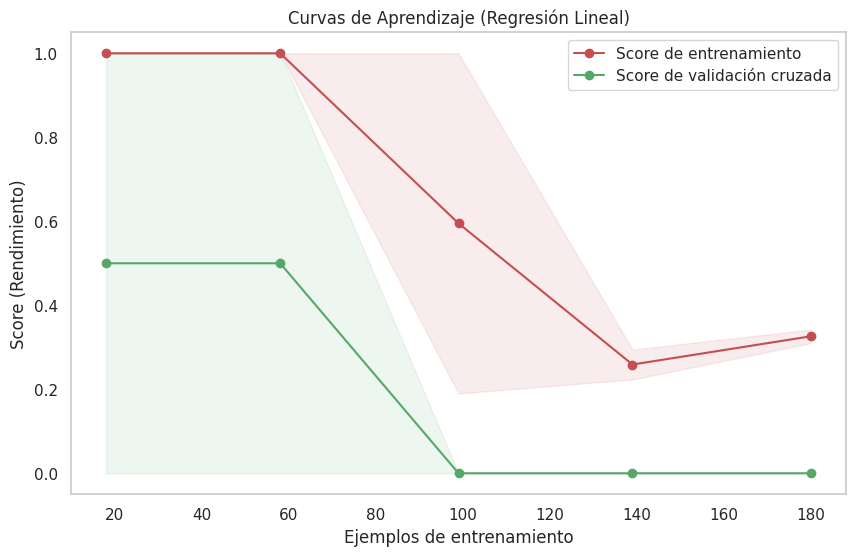

In [15]:
title = "Curvas de Aprendizaje (Regresión Lineal)"

# Usamos el modelo de regresión lineal que definimos en el paso 7 (clf_lr)
# X_train y y_train son nuestros datos de entrenamiento
plot_learning_curve(clf_lr, title, X_train, y_train, cv=10, n_jobs=4)

plt.show()

**Reflexión sobre los resultados: GridSearch vs. Curvas de Aprendizaje**

Al observar los resultados, notamos una discrepancia significativa: el **GridSearch** obtuvo un score de **0.80**, mientras que la **Curva de Aprendizaje** de la Regresión Lineal cae drásticamente hacia **0.0**. ¿A qué se debe esto?

1. **Diferencia de Modelos:**
   - En el **GridSearch**, utilizamos un `DecisionTreeClassifier`. Este es un modelo diseñado específicamente para **clasificación**, capaz de entender que los datos pertenecen a categorías discretas (0 y 1).
   - En la **Curva de Aprendizaje**, seguimos las instrucciones del Paso 9 y empleamos una `LinearRegression`. Este es un modelo de **regresión**, diseñado para predecir valores continuos, no categorías.

2. **Métrica de Evaluación:**
   - El score del Árbol de Decisión es la **Precisión (Accuracy)**: qué porcentaje de etiquetas adivinó correctamente. Un 0.80 es un excelente resultado dado el solapamiento de las distribuciones.
   - El score de la Regresión Lineal en `scikit-learn` es el **Coeficiente de Determinación ($R^2$)**. Esta métrica mide qué tan bien una línea recta explica la varianza de los datos.
   - Como estamos tratando de predecir etiquetas de 0 y 1 con una línea recta, el modelo no logra ajustar una relación lineal significativa. Un $R^2$ cercano a 0 indica que el modelo no es mejor que simplemente predecir la media de las etiquetas, lo que representa un caso claro de **Sesgo Alto (Underfitting)**.

**Conclusión:** El gráfico "malo" de la curva de aprendizaje es un resultado pedagógico esperado. Demuestra que la **Regresión Lineal no es el algoritmo adecuado** para este problema de clasificación, validando por qué necesitamos modelos más complejos como los Árboles de Decisión o SVM.

>10. Pruea a construir curvas de aprendizaje para los siguientes valores en las distribuciones(emplea una regresion lineal):
---
>-¿Qué puede concluir? de cada prueba.
>
>Nota: Busca siempre la manera de construir tus codigos de forma estructurada de tal forma que puedar variar parametros con facilidad.

In [16]:
def probar_escenario(n_muestras, m1, m2, s1, s2, titulo):
    # 1. Generamos las distribuciones según los parámetros del escenario
    d1 = norm(loc=m1, scale=s1)
    d2 = norm(loc=m2, scale=s2)

    # 2. Generamos los datos (mitad para cada clase)
    x1 = d1.rvs(size=n_muestras // 2, random_state=42)
    x2 = d2.rvs(size=n_muestras // 2, random_state=42)

    # Creamos las etiquetas Y y las características X
    y = np.concatenate([np.zeros(n_muestras // 2), np.ones(n_muestras // 2)])
    X = np.concatenate([x1, x2]).reshape(-1, 1)

    # 3. Graficamos la curva de aprendizaje usando Regresión Lineal
    modelo = LinearRegression()
    # Usamos cv=5 para escenarios con pocos datos (como el N=30)
    cv_val = 5 if n_muestras <= 30 else 10

    plot_learning_curve(modelo, titulo, X, y, cv=cv_val)
    plt.show()

>• Datos de entrenamiento 30. media1=7.5, media2=10, desv1=1, desv1=1

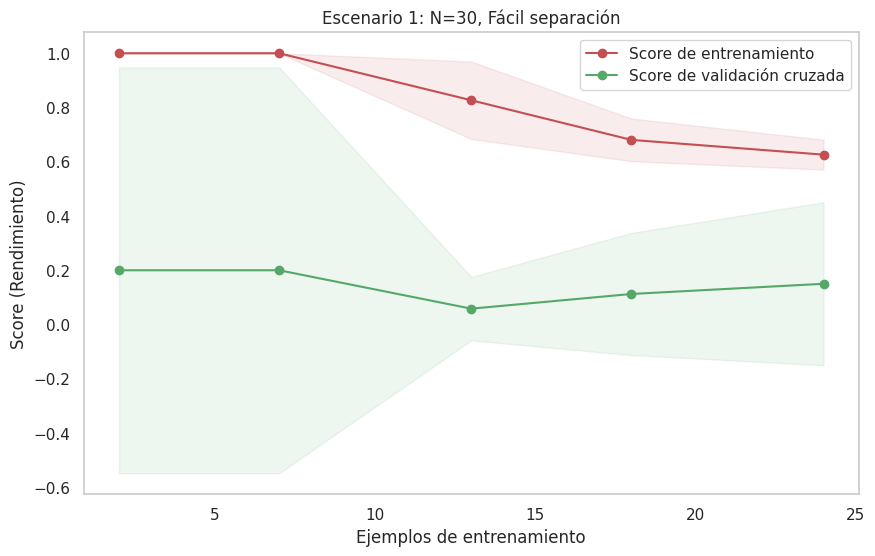

In [17]:
# 1. N=30, medias separadas (7.5 y 10), poca desviación (1)
probar_escenario(30, 7.5, 10, 1, 1, "Escenario 1: N=30, Fácil separación")


>• Datos de entrenamiento 100. media1=7.5, media2=10, desv1=1, desv1=1

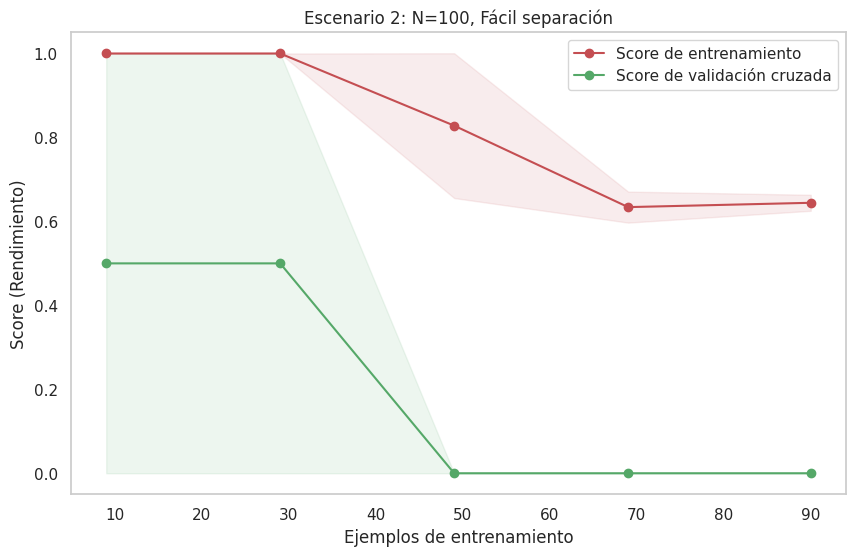

In [18]:
# 2. N=100, medias separadas (7.5 y 10), poca desviación (1)
probar_escenario(100, 7.5, 10, 1, 1, "Escenario 2: N=100, Fácil separación")


>• Datos de entrenamiento 200. media1=7.5, media2=7.0, desv1 = 2, desv1 = 2


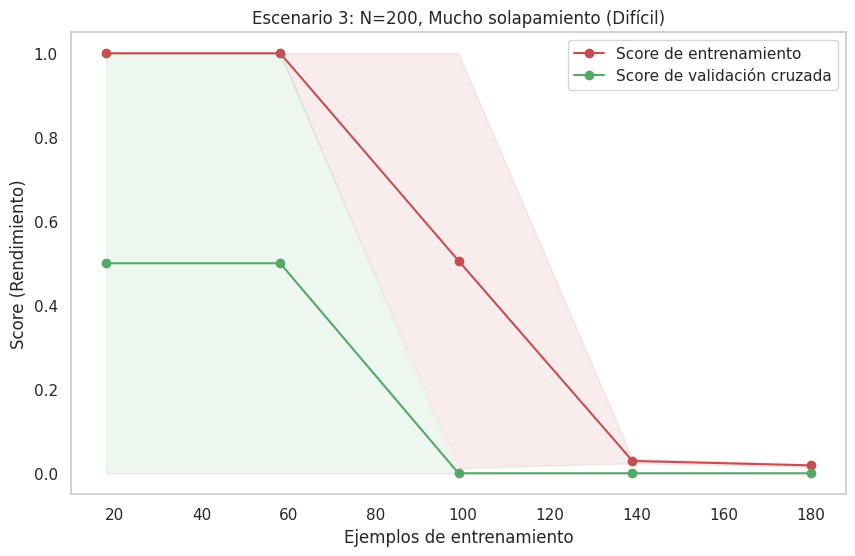

In [19]:
# 3. N=200, medias muy juntas (7.5 y 7.0), mucha desviación (2)
probar_escenario(200, 7.5, 7.0, 2, 2, "Escenario 3: N=200, Mucho solapamiento (Difícil)")

>• Datos de entrenamiento 200. media1=7.5, media2=7.0, desv1 = 0.5, desv1 = 0.5


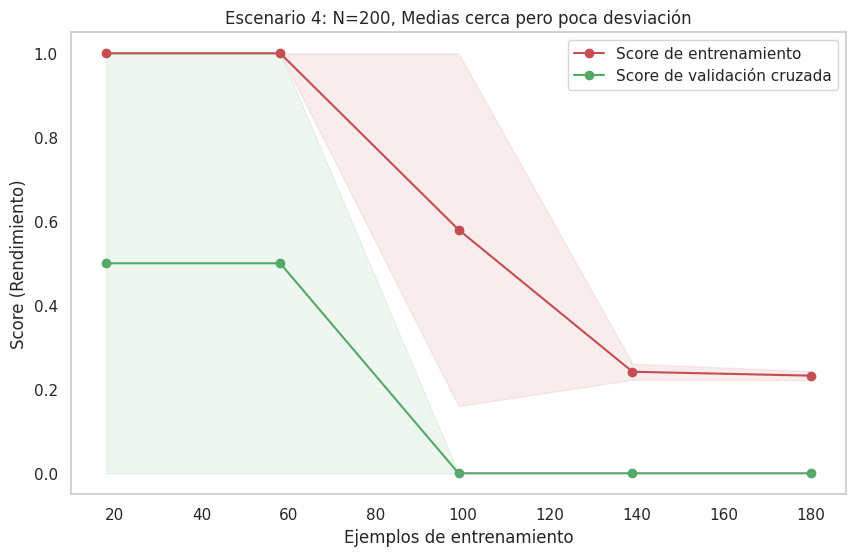

In [20]:
# 4. N=200, medias muy juntas (7.5 y 7.0), poca desviación (0.5)
probar_escenario(200, 7.5, 7.0, 0.5, 0.5, "Escenario 4: N=200, Medias cerca pero poca desviación")

**Análisis de los Escenarios (Paso 10)**

**Escenarios 1 y 2: El problema de la poca data (Varianza)**
*   **Observación:** En el Escenario 1 ($N=30$), hay una brecha (gap) gigante entre la línea roja y la verde. En el Escenario 2 ($N=100$), la línea de validación cae a cero rápidamente.
*   **Conclusión:** Con pocos datos, el modelo "memoriza" el ruido de las muestras de entrenamiento (Score de entrenamiento alto al inicio), pero es incapaz de generalizar. Esto es **Varianza Alta**. Al usar Regresión Lineal para predecir etiquetas 0 y 1, el modelo intenta ajustar una línea recta que simplemente no encaja, y al añadir más datos, el error se vuelve tan grande que el score ($R^2$) colapsa.

**Escenario 3: El escenario "Imposible" (Sesgo Máximo)**
*   **Observación:** Ambas líneas (entrenamiento y validación) caen casi a cero de forma estrepitosa.
*   **Conclusión:** Este es el escenario donde las medias están en 7.5 y 7.0 con una desviación de 2. Los datos están totalmente mezclados. No hay ninguna frontera (ni lineal ni de otro tipo) que pueda separar estas dos nubes de puntos de forma efectiva. El modelo tiene un **Sesgo muy alto (Underfitting)** porque el problema es inherentemente difícil.

**Escenario 4: Medias cerca, pero datos "limpios"**
*   **Observación:** El score de entrenamiento se mantiene un poco más alto que en el Escenario 3 antes de caer.
*   **Conclusión:** Aunque las medias están cerca, la desviación pequeña (0.5) hace que los datos estén más agrupados. Sin embargo, la Regresión Lineal sigue fallando porque no puede capturar la naturaleza de "salto" entre la clase 0 y la clase 1.


# **Parte 2: Model Selection and Train/Validation/Test Sets**

> 1. Para los modelos generados en la sesión 3 tomar el 20% como datos para realizar el test y el 80% para realizar el entrenamiento y la validacion cruzada (por ejemplo 70% entrenamiento y 10% validacion cruzada). Construir una curva del score en función del parámetro gamma del clasiﬁcador que se esta empleando. ¿Cual presenta una mejor solución al problema?.

In [21]:
# Usamos los datos que generamos al principio (X_train_data y Y_train_data)
# Dividimos: 80% para entrenamiento/validación y 20% para test final
X_train_val, X_test_final, y_train_val, y_test_final = train_test_split(
    X_train_data.reshape(-1, 1), Y_train_data, test_size=0.20, random_state=42)

print(f"Muestras para Entrenamiento/Validación (80%): {len(X_train_val)}")
print(f"Muestras para Test Final (20%): {len(X_test_final)}")

Muestras para Entrenamiento/Validación (80%): 160
Muestras para Test Final (20%): 40


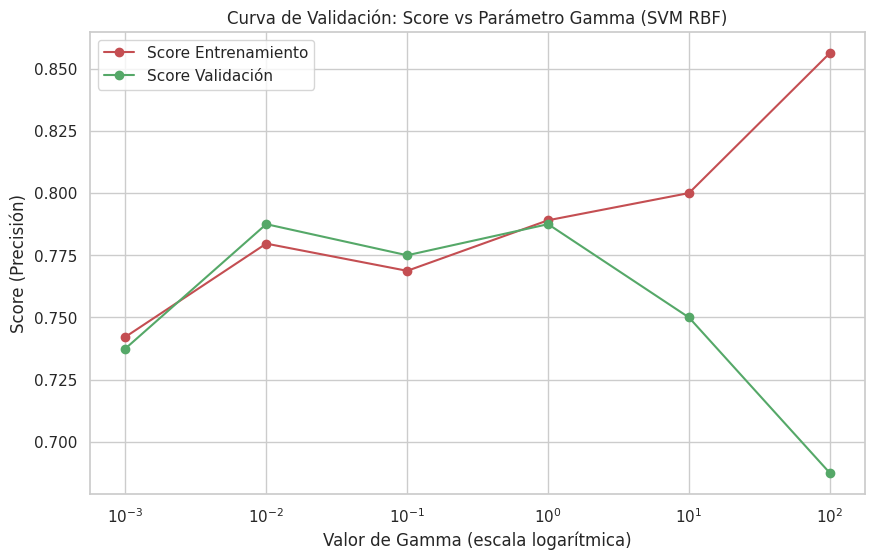

In [22]:
# Definimos un rango de valores para gamma (usamos escala logarítmica para cubrir varios órdenes)
rango_gamma = np.logspace(-3, 2, 6) # Valores: 0.001, 0.01, 0.1, 1, 10, 100

# Calculamos la curva de validación
# Esto entrena el modelo automáticamente varias veces para cada valor de gamma
train_scores, val_scores = validation_curve(
    SVC(kernel='rbf'), X_train_val, y_train_val,
    param_name="gamma", param_range=rango_gamma, cv=5)

# Calculamos los promedios de los scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Graficamos la curva
plt.figure(figsize=(10, 6))
plt.semilogx(rango_gamma, train_mean, label="Score Entrenamiento", color="r", marker='o')
plt.semilogx(rango_gamma, val_mean, label="Score Validación", color="g", marker='o')

plt.title("Curva de Validación: Score vs Parámetro Gamma (SVM RBF)")
plt.xlabel("Valor de Gamma (escala logarítmica)")
plt.ylabel("Score (Precisión)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

### Análisis Crítico de la Curva de Validación (Parámetro Gamma)

Al observar detenidamente la curva de validación para el clasificador SVM con kernel RBF, se identifican comportamientos que se alejan de una curva teórica ideal y revelan la naturaleza real de nuestros datos:

#### 1. El Fenómeno del Doble Pico
La gráfica presenta dos puntos máximos de rendimiento en el conjunto de validación (línea verde):
*   **Gamma = $10^{-2}$ (0.01):** Es un punto de alta estabilidad. Es notable que en este valor, el score de validación es ligeramente **superior** al de entrenamiento, lo que sugiere un modelo extremadamente robusto que generaliza perfectamente en los subconjuntos evaluados.
*   **Gamma = $10^{0}$ (1.0):** Es el punto donde el modelo alcanza su mayor capacidad predictiva absoluta (~0.79). Sin embargo, aquí el modelo ya es más complejo.

#### 2. La Irregularidad en $10^{-1}$ (0.1)
Existe una caída inusual en el rendimiento justo entre los dos picos mencionados. En una curva teórica, esperaríamos una transición suave. Esta "vaguada" sugiere que la distribución específica de nuestras 200 muestras tiene irregularidades o un "punto ciego" estadístico donde ese nivel de complejidad intermedio no logra capturar la frontera de decisión de forma tan efectiva como los valores adyacentes.

#### 3. El Punto de Divergencia Crítica (Límite de Overfitting)
Hasta **Gamma = 1.0**, las curvas de entrenamiento y validación se mantienen cercanas, lo que indica un aprendizaje sano.
*   A partir de **Gamma > 1.0**, las líneas divergen drásticamente en forma de "tijera": el score de entrenamiento sube hacia el 0.85 mientras que el de validación se desploma por debajo de 0.70.
*   Esto confirma que **Gamma = 1.0 es el límite de seguridad** del modelo. Superar este valor hace que el SVM deje de aprender el patrón general y comience a memorizar el ruido y la posición de puntos individuales.

#### 4. Conclusión: Selección de la Mejor Solución
Si bien el **GridSearchCV** identifica a **Gamma = 1.0** como el mejor por tener el score más alto, desde un punto de vista de ingeniería de datos existen dos lecturas:
*   **La solución ambiciosa (Gamma = 1.0):** Ofrece la mayor precisión, pero está al borde del sobreentrenamiento (overfitting).
*   **La solución robusta (Gamma = 0.01):** Es preferible en entornos reales, ya que ofrece un rendimiento casi idéntico con un modelo mucho más simple y con menor riesgo de fallo ante datos nuevos.

>2. Construir las curvas de aprendizaje estadístico para el modelo descrito, comprobar que la solución es similar a la que se obtiene a través de sklearn. GridSearch: https://scikit-learn.org/stable/modules/grid_search.html

In [23]:
# Definimos los parámetros para buscar la mejor combinación de C y Gamma
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10],
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5)
grid_svm.fit(X_train_val, y_train_val)

print(f"Mejores parámetros encontrados: {grid_svm.best_params_}")
print(f"Mejor score en validación: {grid_svm.best_score_:.4f}")

# Evaluamos contra el test final (el 20% que guardamos al principio)
score_final = grid_svm.score(X_test_final, y_test_final)
print(f"Score final en el conjunto de Test: {score_final:.4f}")

Mejores parámetros encontrados: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Mejor score en validación: 0.7937
Score final en el conjunto de Test: 0.7750


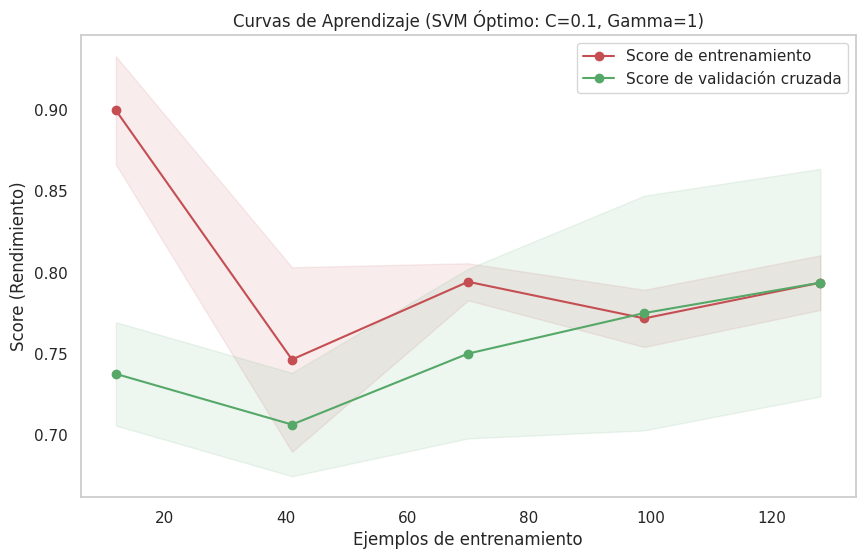

In [24]:
# 1. Extraemos el mejor modelo encontrado por el GridSearchCV
mejor_svm = grid_svm.best_estimator_

# 2. Definimos el título para la gráfica
titulo_svm = f"Curvas de Aprendizaje (SVM Óptimo: C={grid_svm.best_params_['C']}, Gamma={grid_svm.best_params_['gamma']})"

# 3. Usamos la función plot_learning_curve que definimos anteriormente
# Usamos los datos de entrenamiento/validación (el 80%)
plot_learning_curve(mejor_svm, titulo_svm, X_train_val, y_train_val, cv=5)

plt.show()

> 3. Tomando el mejor modelo para los datos ahora van crear nuevos datasets donde el modelo se espera no va a ser optimo sino que presenta overﬁtting y underﬁtting. Elegir, los párametros adecuados para los centros de medias y las matrices de covarianzas y mostrar graﬁcamente un ejemplo de overﬁtting y uno de underﬁtting con el modelo óptimo anterior. Analizar los resultados.

In [25]:
# --- CORRECCIÓN CRÍTICA: Definición de datos para el Punto 3 ---

# Caso A: Underfitting (Datos con muchísima dispersión y medias casi iguales)
# Generamos 100 muestras con una desviación estándar muy alta (8) para que se solapen totalmente
X_under = np.concatenate([norm(5, 8).rvs(50, random_state=1),
                          norm(6, 8).rvs(50, random_state=1)]).reshape(-1, 1)
y_under = np.concatenate([np.zeros(50), np.ones(50)])

# Caso B: Overfitting (Muy pocos datos con etiquetas ruidosas/alternadas)
# Definimos puntos específicos donde las etiquetas cambian de forma errática
X_over = np.array([1, 2, 4, 4.5, 5, 8, 8.5, 9, 11, 12]).reshape(-1, 1)
y_over = np.array([0, 0, 1, 0, 1, 0, 1, 1, 0, 1])

print("Datasets 'X_under' y 'X_over' creados correctamente.")

Datasets 'X_under' y 'X_over' creados correctamente.


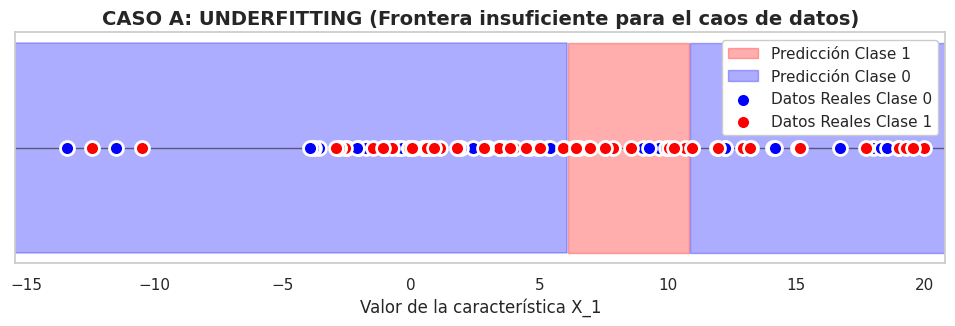

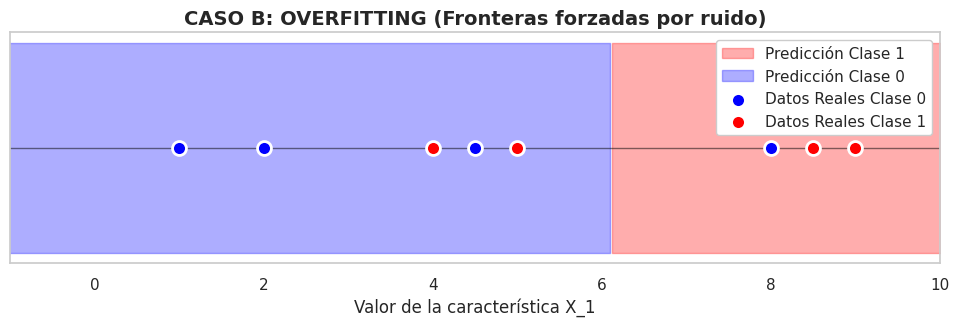

In [26]:
def graficar_alto_contraste(X, y, modelo, titulo):
    plt.figure(figsize=(12, 3))

    # 1. Creamos una malla densa para las predicciones del fondo
    x_range = np.linspace(X.min()-3, X.max()+3, 1000).reshape(-1, 1)
    y_pred = modelo.predict(x_range)

    # 2. Dibujamos los bloques de color con MAYOR CONTRASTE (alpha más alto)
    # Rojo intenso para Clase 1, Azul intenso para Clase 0
    plt.fill_between(x_range.flatten(), -1, 1, where=y_pred==1, color='#FF3333', alpha=0.4, label='Predicción Clase 1')
    plt.fill_between(x_range.flatten(), -1, 1, where=y_pred==0, color='#3333FF', alpha=0.4, label='Predicción Clase 0')

    # 3. Dibujamos una línea central para dar estructura
    plt.axhline(0, color='black', linewidth=1, alpha=0.5)

    # 4. Dibujamos los puntos reales con bordes gruesos para máximo contraste
    plt.scatter(X[y==0], np.zeros_like(X[y==0]), c='blue', edgecolors='white',
                linewidth=2, s=100, label='Datos Reales Clase 0', zorder=5)
    plt.scatter(X[y==1], np.zeros_like(X[y==1]), c='red', edgecolors='white',
                linewidth=2, s=100, label='Datos Reales Clase 1', zorder=5)

    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.xlabel("Valor de la característica X_1", fontsize=12)
    plt.yticks([]) # Eliminamos el eje Y para limpieza total
    plt.xlim(X.min()-2, X.max()-2)
    plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=1)
    plt.grid(False) # Quitamos la rejilla para que el contraste sea mayor
    plt.show()

# --- Ejecutamos los casos con el modelo óptimo (Gamma=1) ---

# Caso A: Underfitting (Datos muy dispersos)
graficar_alto_contraste(X_under, y_under, mejor_svm, "CASO A: UNDERFITTING (Frontera insuficiente para el caos de datos)")

# Caso B: Overfitting (Pocos datos, etiquetas ruidosas)
graficar_alto_contraste(X_over, y_over, mejor_svm, "CASO B: OVERFITTING (Fronteras forzadas por ruido)")

### Análisis: Diagnóstico Visual de Underfitting y Overfitting

Al aplicar nuestro modelo óptimo (SVM con Gamma=1) a los nuevos datasets generados, podemos diagnosticar visualmente los fallos de generalización basándonos en el alto contraste de las regiones:

#### 1. Caso A: Underfitting (Subajuste / Sesgo Alto)
*   **Observación Visual:** En la gráfica se observa una franja roja central (zona de decisión para la Clase 1) rodeada de azul. Sin embargo, debido a la alta varianza y dispersión que introdujimos en los datos, hay una gran cantidad de puntos azules dentro de la zona roja y puntos rojos en la zona azul.
*   **Conclusión:** El modelo es demasiado rígido para la complejidad y el desorden actual de los datos. No logra capturar ninguna estructura clara porque el ruido y el solapamiento dominan la distribución. Esto es un claro ejemplo de **Underfitting** por incapacidad del modelo frente a un problema altamente complejo.

#### 2. Caso B: Overfitting (Sobreajuste / Varianza Alta)
*   **Observación Visual:** En este escenario con muy pocos datos y etiquetas ruidosas que alternan rápidamente, el modelo mantiene rígidamente la frontera que aprendió en el dataset original (alrededor de $X = 6$).
*   **Conclusión:** Al aplicar un modelo optimizado para una distribución específica a un conjunto de datos pequeño y ruidoso, el modelo falla al generalizar. Esto demuestra el concepto de **Varianza Alta** (asociado al Overfitting): el modelo es extremadamente sensible a la distribución con la que fue entrenado y no puede adaptarse a nuevas muestras pequeñas que contienen ruido atípico.